In [1]:
from google.colab import files
uploaded = files.upload()

Saving house Prediction Data Set.csv to house Prediction Data Set.csv


**Task** 4 :


Import Libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [14]:
df = pd.read_csv("house Prediction Data Set.csv" , delim_whitespace=True, header=None)
df.head()

/tmp/ipykernel_1668/1967778989.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("house Prediction Data Set.csv" , delim_whitespace=True, header=None)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


Check Dataset Info

In [15]:
df.shape

(506, 14)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       506 non-null    float64
 1   1       506 non-null    float64
 2   2       506 non-null    float64
 3   3       506 non-null    int64  
 4   4       506 non-null    float64
 5   5       506 non-null    float64
 6   6       506 non-null    float64
 7   7       506 non-null    float64
 8   8       506 non-null    int64  
 9   9       506 non-null    float64
 10  10      506 non-null    float64
 11  11      506 non-null    float64
 12  12      506 non-null    float64
 13  13      506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [17]:
df.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], dtype='int64')

In [18]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


Basic Cleaning

In [19]:
df = df.dropna()
df.shape

(506, 14)

Check Column


In [20]:
df.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], dtype='int64')

Vidualization

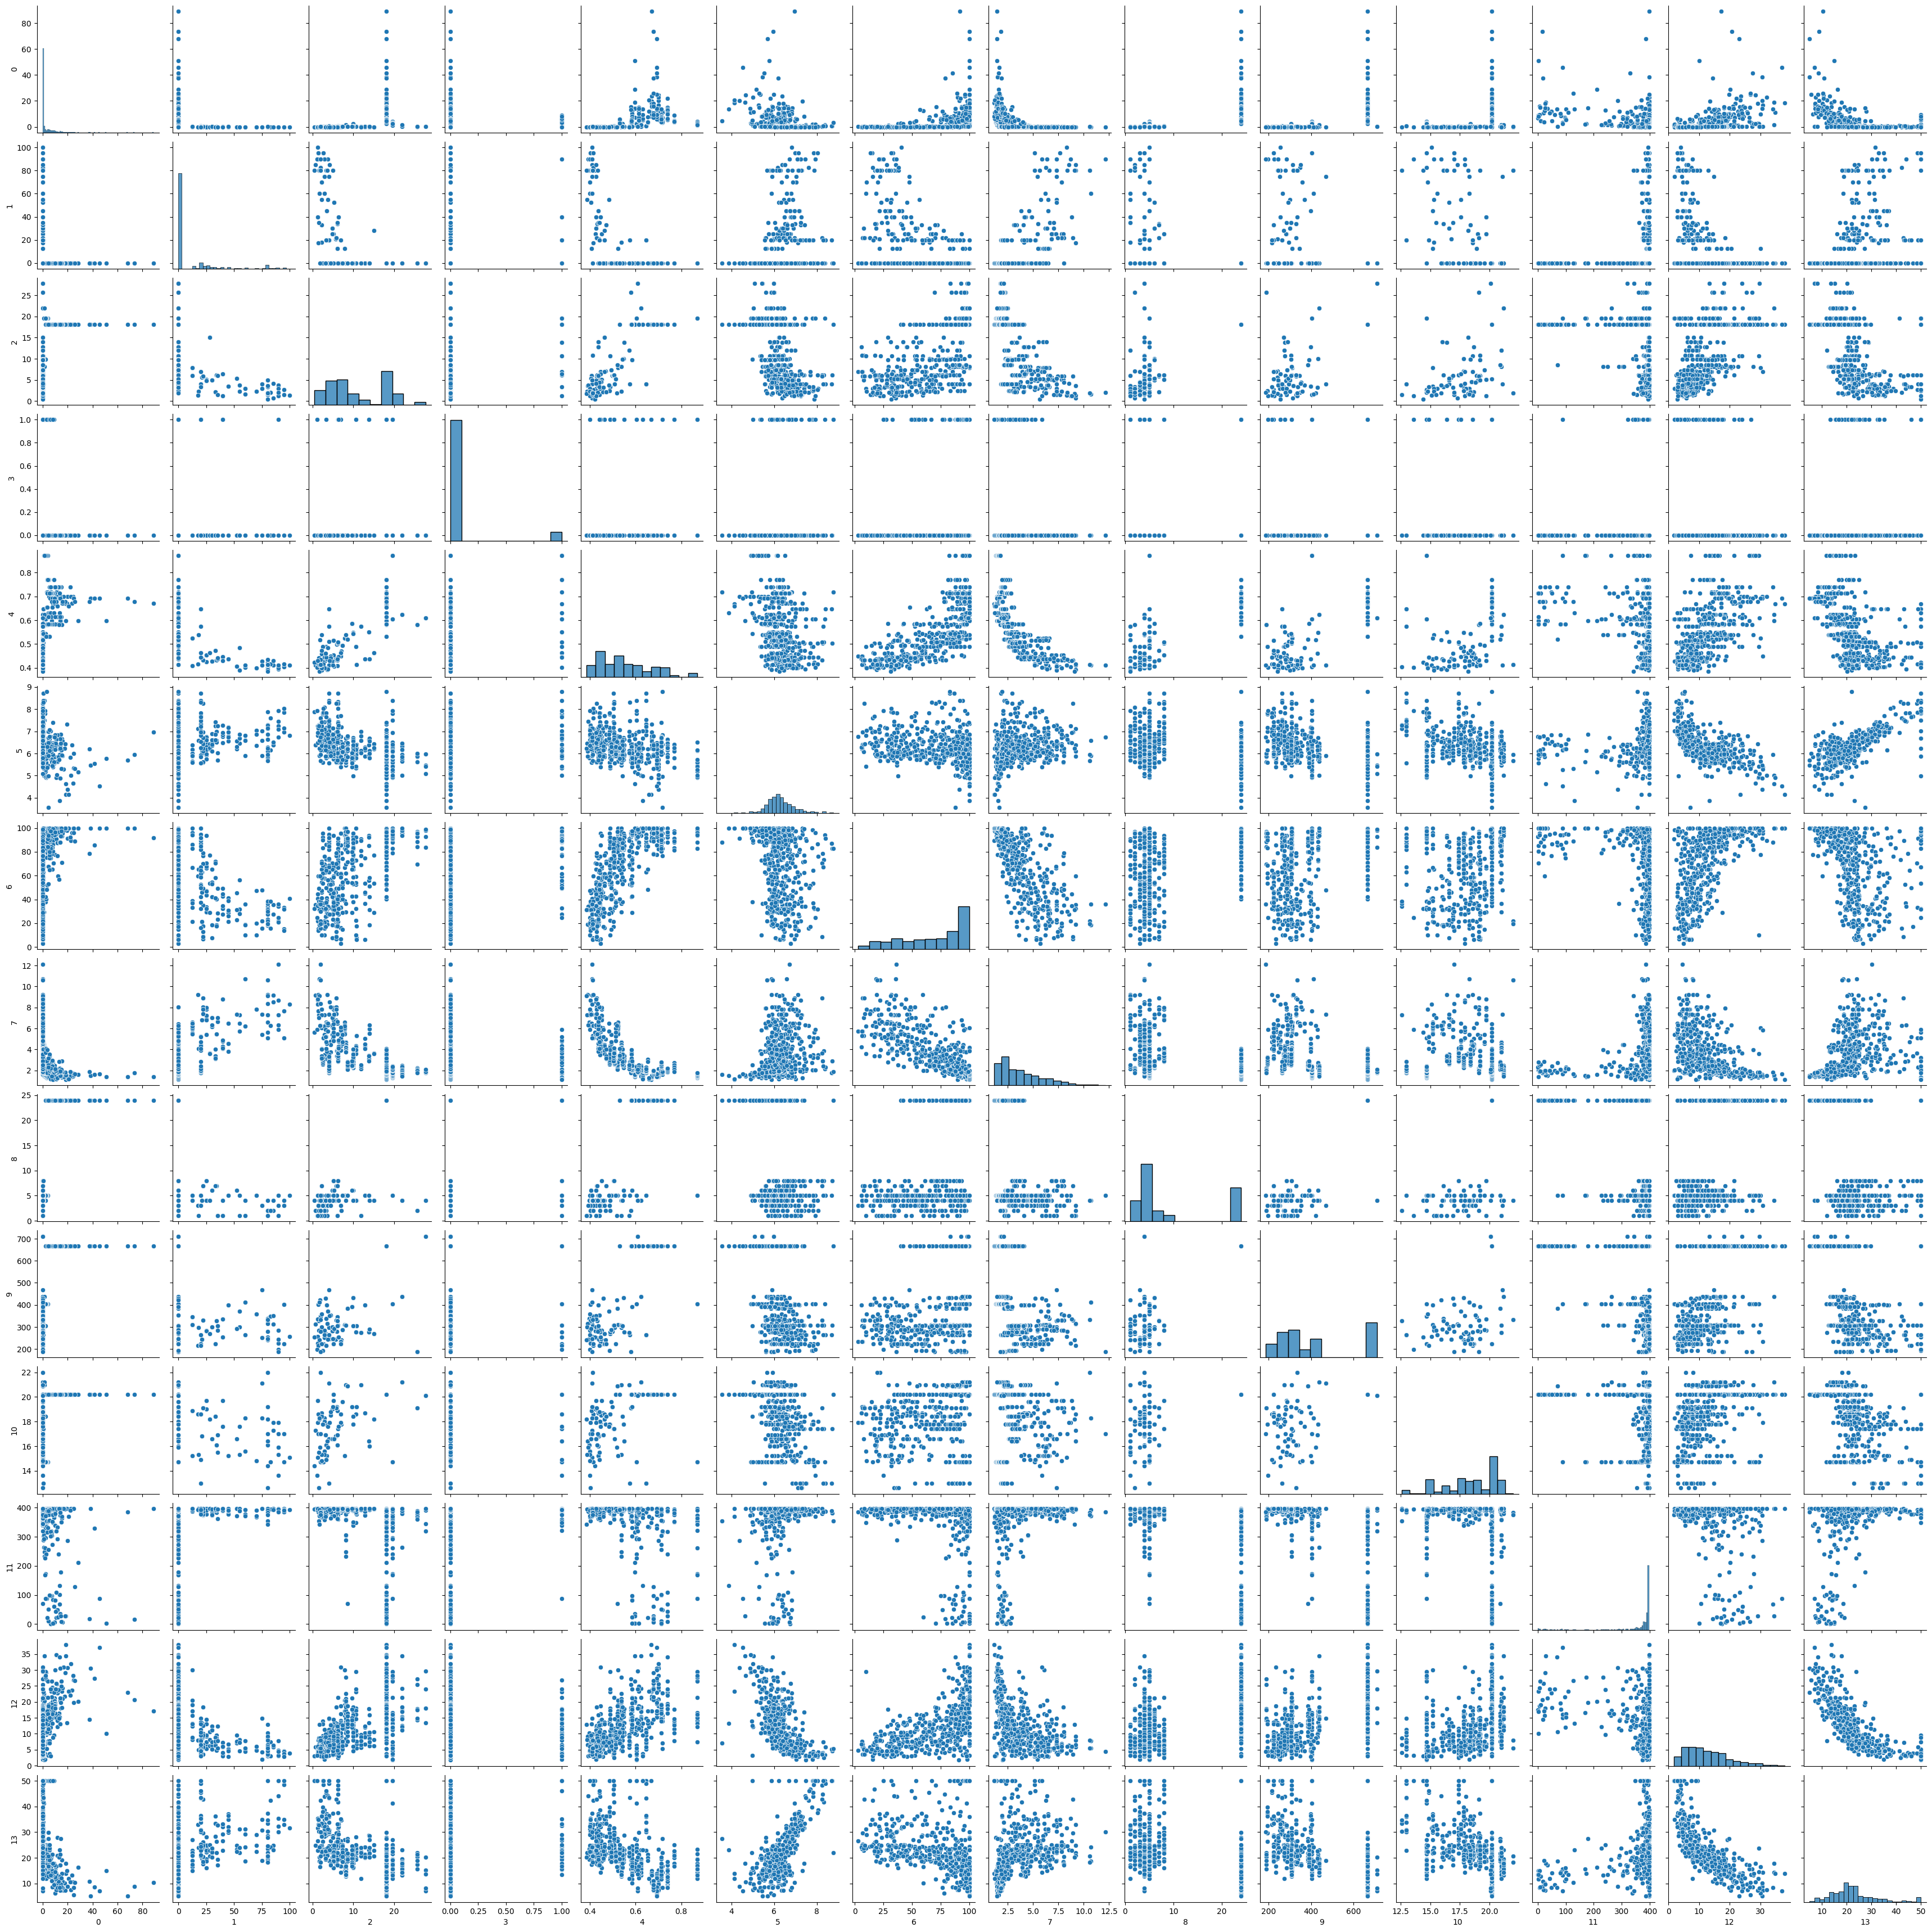

In [21]:
sns.pairplot(df)
plt.show()

Correlation Heatmap


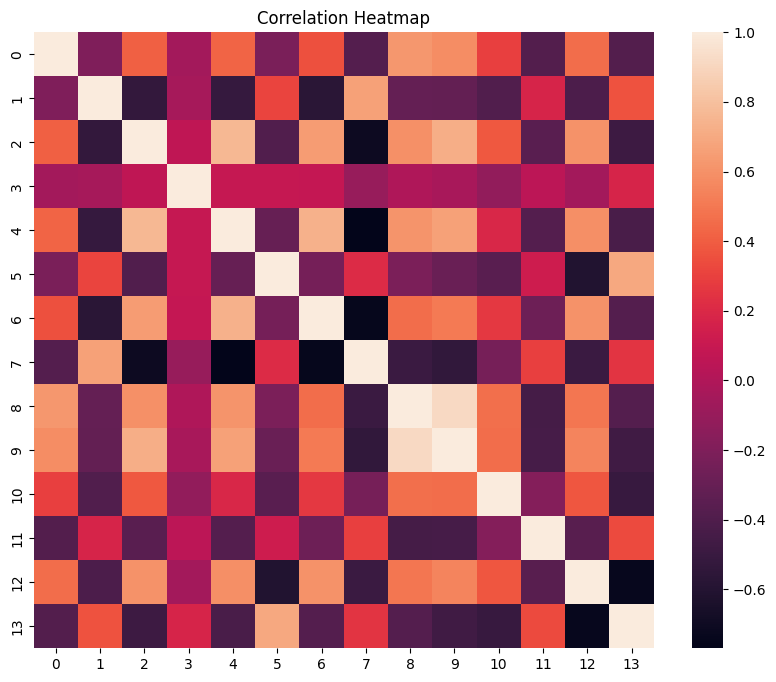

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

Selecting Features & Target

In [23]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [24]:
print(X.shape)
print(y.shape)

(506, 13)
(506,)


Train Test Split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)


(404, 13)
(102, 13)


Train the Model

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Prediction


In [29]:
pred = model.predict(X_test)
pred[:5]

array([28.99672362, 36.02556534, 14.81694405, 25.03197915, 18.76987992])

Model Evaluation


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 3.189091965887837
MSE: 24.291119474973478
R2 Score: 0.6687594935356326


Compare Results

In [33]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

result.head()

,Actual,Predicted
173,23.6,28.996724
274,32.4,36.025565
491,13.6,14.816944
72,22.8,25.031979
452,16.1,18.769880


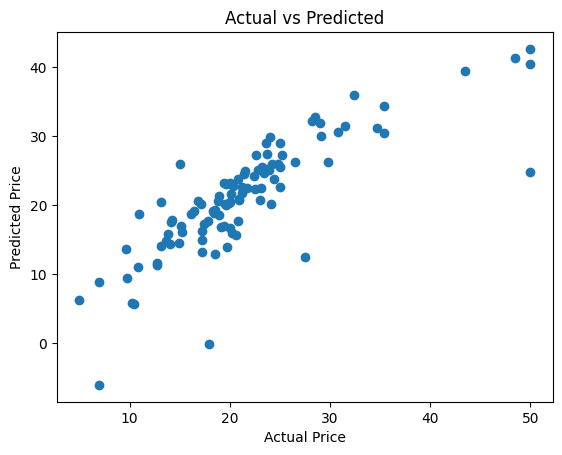

In [32]:
plt.scatter(y_test, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

pred2 = rf.predict(X_test)

print("R2 Score (RF):", r2_score(y_test, pred2))

R2 Score (RF): 0.8814242600981215


Conclusion:


In this project, we built a house price prediction model using Machine Learning techniques.
We applied Linear Regression and Random Forest algorithms.
The Random Forest model performed better with an R2 score of 0.88, indicating strong predictive performance.
This model can be used to estimate house prices based on various features.